# Complex Systems

Implement a computer code for Deffuant’s bounded confidence model in a globally coupled network
of $N$ agents with approaching parameter $\mu$ and interaction threshold $d$ (see Class Notes). You may use the programming language of your choice. Plot the temporal evolution of the opinion states of the $N = 500$ agents until clusters are formed, with fixed parameters:

a) $\mu = 0.5$, $d = 0.1$

b) $\mu = 0.5$, $d = 0.4$

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scienceplots

# Define the style
plt.style.use(['science', 'notebook', 'no-latex']) # Use a specific style for figures

In [160]:
class DeffuantModel:
    """
    Deffuant bounded confidence model on a globally connected network.
    Parameters:
        N (int): Number of agents
        mu (float): Convergence/approaching parameter (0 < μ ≤ 0.5)
        d (float): Confidence threshold
        T (int): Number of iterations
    """

    def __init__(self, N=500, mu=0.5, d=0.2, T=200000):
        self.N = N
        self.mu = mu
        self.d = d
        self.T = T

        # Define a seed for reproducibility
        np.random.seed(84572947)

        # initial opinion distribution
        self.opinions = np.random.rand(N)

        # initial uniform distribution
        #self.opinions = np.linspace(0, 1, N)

        # temporal storage
        self.history = []

    def step(self):
        """One interaction: pick two random agents, update if |xi - xj| < d."""
        i, j = np.random.choice(self.N, size=2, replace=False)
        xi, xj = self.opinions[i], self.opinions[j]
        dist = abs(xi - xj)

        if dist < self.d:  # compromise
            new_xi = xi + self.mu * (xj - xi)
            new_xj = xj + self.mu * (xi - xj)
            self.opinions[i] = new_xi
            self.opinions[j] = new_xj

    def run(self):
        """Run the model and record history every 100 steps."""
        for t in range(self.T):
            # save each 200 steps
            if t % 100 == 0:
                self.history.append(self.opinions.copy())
            self.step()

        self.history = np.array(self.history)
        return self.history

    def plot_evolution(self, color_scatter="black", save=False, outdir="results", name="experiment"):
        """
        Plot time evolution of opinions.
        Inputs:
            save (bool): Whether to save the figure
            outdir (str): Directory to save the figure
            name (str): Filename prefix
        Outputs:
            Figure showing opinion trajectories over time.
        """

        plt.figure(figsize=(10, 6))
        time_steps = np.arange(len(self.history))

        # Each agent trajectory
        for i in range(self.N):
            plt.scatter(time_steps, self.history[:, i], color=color_scatter,
                        s=5, alpha=0.2, lw=0.3)
        plt.xlabel(r"Time Steps $\times$ 100")
        plt.ylabel("Opinion")
        plt.title(f"Deffuant Model\nN={self.N}, " + r"$\mu$" + f"={self.mu}, d={self.d}")
        plt.grid(alpha=0.3)
        plt.xlim(0, len(self.history))

        if save:
            # Make directory if it doesn't exist
            if not os.path.exists(outdir):
                os.makedirs(outdir)

            filename = f"{name}_N{self.N}_mu{self.mu}_d{self.d}.png"
            filepath = os.path.join(outdir, filename)

            plt.savefig(filepath, dpi=300)
            plt.show()
            plt.close()
            print(f"Figure saved at: {filepath}")
        else:
            plt.show()

a)

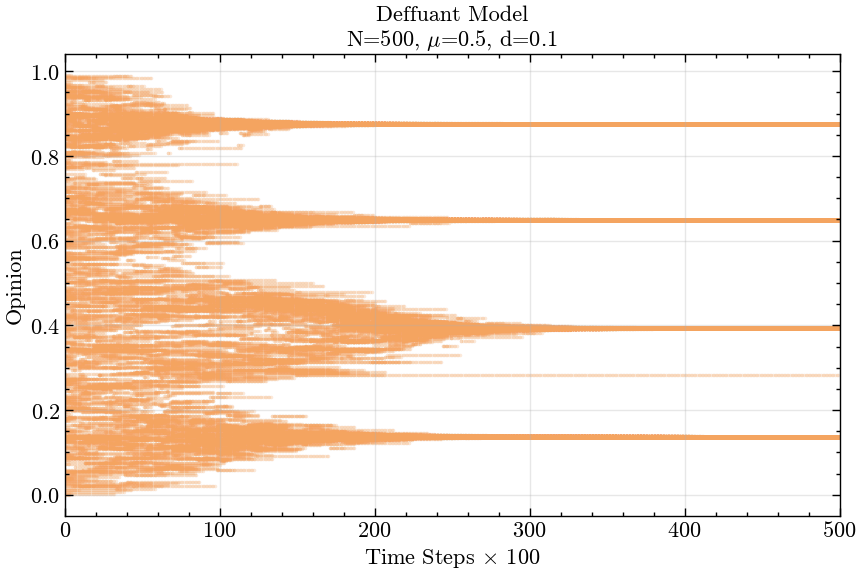

Figure saved at: output/case_a_N500_mu0.5_d0.1.png


In [161]:
modela = DeffuantModel(N=500, mu=0.5, d=0.1, T=50000)
modela.run()
modela.plot_evolution(save=True, outdir="output", name="case_a", color_scatter="sandybrown")

b)

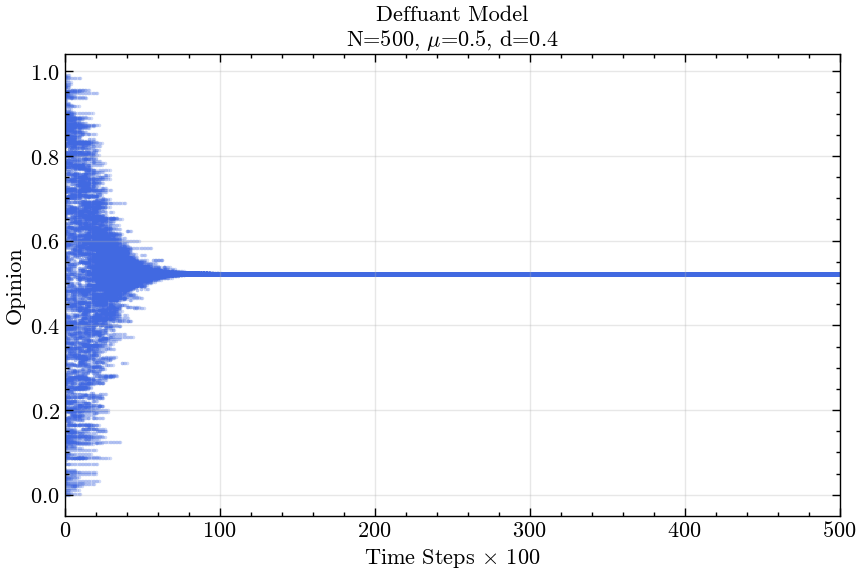

Figure saved at: output/case_b_N500_mu0.5_d0.4.png


In [162]:
modelb = DeffuantModel(N=500, mu=0.5, d=0.4, T=50000)
modelb.run()
modelb.plot_evolution(save=True, outdir="output", name="case_b", color_scatter="royalblue")